In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [11]:
df = pd.read_csv("../data/listings.csv")
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,155305,https://www.airbnb.com/rooms/155305,20250922033920,2025-09-22,city scrape,Cottage! BonPaul + Sharky's Hostel,West Asheville Cottage within walking distance...,"We are within easy walk of pubs, breweries, mu...",https://a0.muscache.com/pictures/hosting/Hosti...,746673,...,4.75,4.92,4.58,NaN,t,8,2,3,3,2.69
1,197263,https://www.airbnb.com/rooms/197263,20250922033920,2025-09-22,city scrape,Tranquil Room & Private Bath,"This is a comfy, peaceful and clean room with ...",NaN,https://a0.muscache.com/pictures/miso/Hosting-...,961396,...,4.90,4.86,4.97,NaN,f,2,1,1,0,0.56
2,209068,https://www.airbnb.com/rooms/209068,20250922033920,2025-09-22,city scrape,Terrace Cottage,Located in one of Asheville's oldest historic ...,Our beautiful Grove Park Historic District clo...,https://a0.muscache.com/pictures/1829924/9f3bf...,1029919,...,4.98,4.94,4.80,NaN,f,1,1,0,0,0.39
3,246315,https://www.airbnb.com/rooms/246315,20250922033920,2025-09-22,city scrape,Asheville Dreamer's Cabin,"Hi there,<br />I am usually here half of each ...",NaN,https://a0.muscache.com/pictures/5908617/cfe79...,1292070,...,4.65,4.67,4.59,NaN,f,3,2,1,0,0.31
4,314540,https://www.airbnb.com/rooms/314540,20250922033920,2025-09-22,city scrape,Asheville Urban Farmhouse Entire Home 4.6 mi t...,Farmhouse in the city is OPEN! This charming 1...,City vibes with country appeal. Peaceful neigh...,https://a0.muscache.com/pictures/hosting/Hosti...,381660,...,4.97,4.91,4.91,NaN,t,1,1,0,0,0.22


In [12]:
df.shape

(2852, 79)

In [13]:
df.columns.tolist()

['id',
 'listing_url',
 'scrape_id',
 'last_scraped',
 'source',
 'name',
 'description',
 'neighborhood_overview',
 'picture_url',
 'host_id',
 'host_url',
 'host_name',
 'host_since',
 'host_location',
 'host_about',
 'host_response_time',
 'host_response_rate',
 'host_acceptance_rate',
 'host_is_superhost',
 'host_thumbnail_url',
 'host_picture_url',
 'host_neighbourhood',
 'host_listings_count',
 'host_total_listings_count',
 'host_verifications',
 'host_has_profile_pic',
 'host_identity_verified',
 'neighbourhood',
 'neighbourhood_cleansed',
 'neighbourhood_group_cleansed',
 'latitude',
 'longitude',
 'property_type',
 'room_type',
 'accommodates',
 'bathrooms',
 'bathrooms_text',
 'bedrooms',
 'beds',
 'amenities',
 'price',
 'minimum_nights',
 'maximum_nights',
 'minimum_minimum_nights',
 'maximum_minimum_nights',
 'minimum_maximum_nights',
 'maximum_maximum_nights',
 'minimum_nights_avg_ntm',
 'maximum_nights_avg_ntm',
 'calendar_updated',
 'has_availability',
 'availability_30

In [15]:
needed_cols = ["price", "room_type", "accommodates", "bedrooms", "beds", "bathrooms", "latitude", "longitude", "neighbourhood_cleansed", "review_scores_rating", "review_scores_cleanliness", "review_scores_location", "review_scores_value", "host_is_superhost", "instant_bookable", "amenities"]

In [19]:
#clean the dataset to only include those (most signfiicant) values to determine cost
df = df[needed_cols].copy()
df.head()

,price,room_type,accommodates,bedrooms,beds,bathrooms,latitude,longitude,neighbourhood_cleansed,review_scores_rating,review_scores_cleanliness,review_scores_location,review_scores_value,host_is_superhost,instant_bookable,amenities
0,$96.00,Entire home/apt,2,1.0,1.0,1.0,35.578640,-82.595780,28806,4.62,4.46,4.92,4.58,t,t,"[""Coffee maker"", ""Wifi"", ""Fire extinguisher"", ..."
1,$44.00,Private room,2,1.0,1.0,1.0,35.577350,-82.638040,28806,4.92,4.98,4.86,4.97,t,f,"[""Electric stove"", ""Clothing storage: closet"",..."
2,$90.00,Entire home/apt,4,1.0,2.0,1.0,35.617641,-82.551819,28804,4.89,4.85,4.94,4.80,f,f,"[""Coffee maker"", ""Clothing storage: walk-in cl..."
3,$62.00,Private room,2,1.0,1.0,1.0,35.596150,-82.506350,28805,4.66,4.57,4.67,4.59,f,f,"[""Coffee maker"", ""Wifi"", ""Dishwasher"", ""Fire e..."
4,$221.00,Entire home/apt,6,4.0,5.0,2.0,35.585610,-82.627310,28806,4.94,4.91,4.91,4.91,t,t,"[""Garden view"", ""Outdoor dining area"", ""Clothi..."


In [27]:
#make prices normal floats
df["price"] = (df["price"].astype(str).str.lstrip("$").str.replace(",", "").astype(float))
df["price"].head()

0     96.0
1     44.0
2     90.0
3     62.0
4    221.0
Name: price, dtype: float64

In [29]:
#statistical methods on price col
print(df["price"].describe())

count    2537.000000
mean      196.383918
std       405.674986
min        18.000000
25%        95.000000
50%       133.000000
75%       211.000000
max      9999.000000
Name: price, dtype: float64


In [32]:
#used this to figure out which columns have a significant lack of data and how significant that problem is.
df.isnull().sum()

price                        315
room_type                      0
accommodates                   0
bedrooms                      36
beds                         316
bathrooms                    306
latitude                       0
longitude                      0
neighbourhood_cleansed         0
review_scores_rating         243
review_scores_cleanliness    243
review_scores_location       243
review_scores_value          243
host_is_superhost             44
instant_bookable               0
amenities                      0
dtype: int64

#### With almost 3000 rows, this problem isn't too signficant, but we will need to drop a few rows that have Na values for price, for instance. 

In [33]:
#dropping rows with na for price, since it is the most important thing for our model
df = df.dropna(subset=["price"])

In [35]:
#for bedrooms, we have 36 values missing, so we'll just fill them in with the median (and not have too much deviation)
df["bedrooms"] = df["bedrooms"].fillna(df["bedrooms"].median())

In [36]:
#we will also fill in the median for almost everything else, since we are missing at maximum around 10% of values, and adding the median to them won't affec the model too much
df["bathrooms"] = df["bathrooms"].fillna(df["bathrooms"].median())
df["beds"] = df["beds"].fillna(df["beds"].median())

In [46]:
#fill in review values with zero
review_cols = ["review_scores_rating", "review_scores_cleanliness", "review_scores_location", "review_scores_value"]
for col in review_cols:
    df[col] = df[col].fillna(0)

In [48]:
#review scores that are missing, we will just put in as zero right now into a new column that checks whether the airbnb has a ranking and acknowledge in our model later (model differentiates between reviewd and new listings)
df["has_reviews"] = (df["review_scores_rating"] > 0).astype(int)

In [40]:
#right now, host is superhost is represented as t or f, and so for the 44 missing host_is_superhost values we will assume false
df["host_is_superhost"] = df["host_is_superhost"].fillna("f")
#now we want to map to numbers to make it easier for data analysis
df["host_is_superhost"] = df["host_is_superhost"].map({"t": 1, "f": 0})

In [49]:
#now all na values are taken care of, so the dataset has these characteristic
print(df.isnull().sum())
print(df.shape)

price                        0
room_type                    0
accommodates                 0
bedrooms                     0
beds                         0
bathrooms                    0
latitude                     0
longitude                    0
neighbourhood_cleansed       0
review_scores_rating         0
review_scores_cleanliness    0
review_scores_location       0
review_scores_value          0
host_is_superhost            0
instant_bookable             0
amenities                    0
has_reviews                  0
dtype: int64
(2537, 17)


In [50]:
#It is easier to deal with ammenties as numbers rather than strings, so we will count the number of ammenities and add it to a new amenities_count column
df["amenities_count"] = df["amenities"].apply(lambda x: len(str(x).split(",")))

In [51]:
#final check
print(df.isnull().sum())

price                        0
room_type                    0
accommodates                 0
bedrooms                     0
beds                         0
bathrooms                    0
latitude                     0
longitude                    0
neighbourhood_cleansed       0
review_scores_rating         0
review_scores_cleanliness    0
review_scores_location       0
review_scores_value          0
host_is_superhost            0
instant_bookable             0
amenities                    0
has_reviews                  0
amenities_count              0
dtype: int64


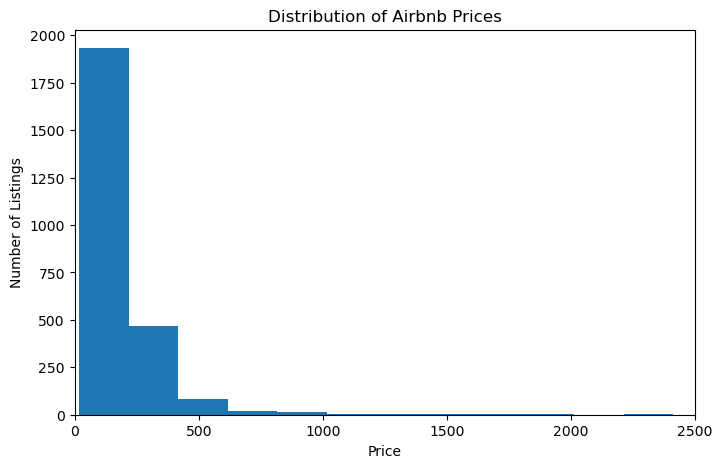

In [57]:
#creating 
plt.figure(figsize=(8,5)) #blank space to draw graph
plt.hist(df["price"], bins=50) #creates histogram with 50 bins based on price
plt.xlim(0, 2500) #want to limit x-axis to avoid skewed graph due to a few high outliers
plt.xlabel("Price")
plt.ylabel("Number of Listings")
#answers the question of how many listings fall into each price range
plt.title("Distribution of Airbnb Prices")
plt.show()

In [63]:
#finding certain extreme percentiles
print("Extreme percentiles:")
print(f"99% {df["price"].quantile(0.99)}")
print(f"95% {df["price"].quantile(0.95)}")
print(f"90% {df["price"].quantile(0.90)}")
print(f"10% {df["price"].quantile(0.10)}")
print(f"5% {df["price"].quantile(0.05)}")
print(f"1% {df["price"].quantile(0.01)}")
print("")
#all other stats
print("stats:")
print(df["price"].describe())

Extreme percentiles:
99% 1023.9999999999936
95% 428.59999999999945
90% 321.0
10% 69.60000000000002
5% 57.0
1% 40.0

stats:
count    2537.000000
mean      196.383918
std       405.674986
min        18.000000
25%        95.000000
50%       133.000000
75%       211.000000
max      9999.000000
Name: price, dtype: float64


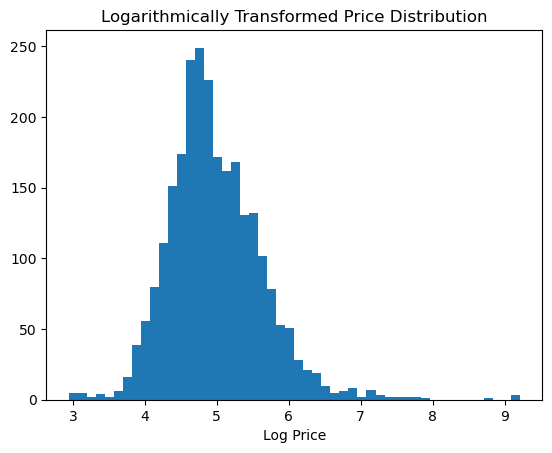

In [66]:
#logarithmic transformation for future modeling as well as so that large values don't dominate the graph
plt.hist(np.log1p(df["price"]), bins=50) #adds 1 before taking log so that there are no undefined values
plt.xlabel("Log Price")
plt.title("Logarithmically Transformed Price Distribution")
plt.show()
#you can see now that the distribution looks signficantly more balanced

In [68]:
#adding log_price row for ease of future analytics
df["log_price"] = np.log1p(df["price"])

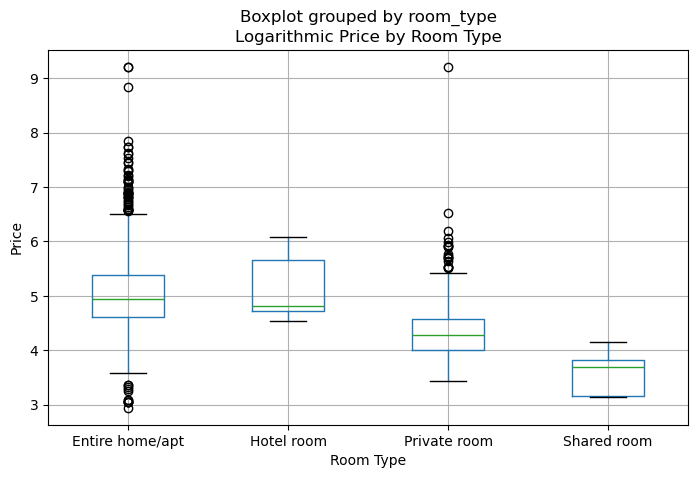

In [69]:
#used log price to avoid extreme outliers
df.boxplot(column="log_price", by="room_type", figsize=(8,5))
plt.title("Logarithmic Price by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Price")
plt.show()

Based on this visualization, most of the time, entire homes/apartments are the most expensive AirBnbs (highest median), but also have the largest range, meaning that hotel rooms certainly have the highest baseline cost (a cheap hotel room is almost the median hotel room). Private rooms follow close after entire homes/hotel rooms, and shared rooms are pretty clearly the cheapest. 

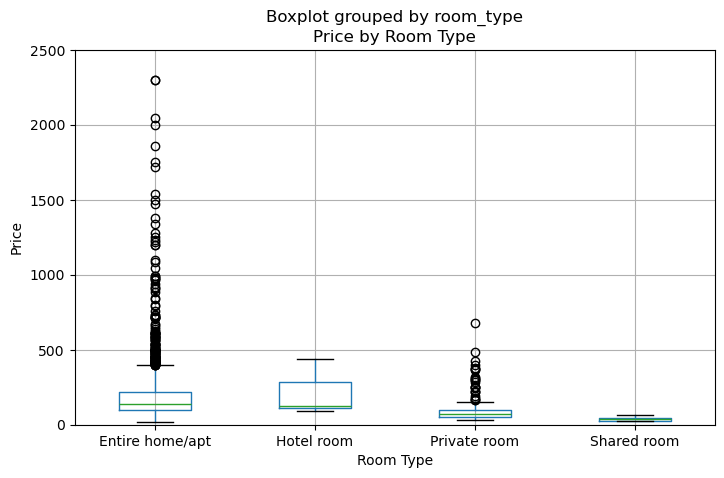

In [73]:
#adding another visualization with limited x_axis just for a better visualization
#here you can clearly see the massively high prices somewhat common in entire home airbnbs
df.boxplot(column="price", by="room_type", figsize=(8,5))
plt.title("Price by Room Type")
plt.ylim(0, 2500)
plt.xlabel("Room Type")
plt.ylabel("Price")
plt.show()

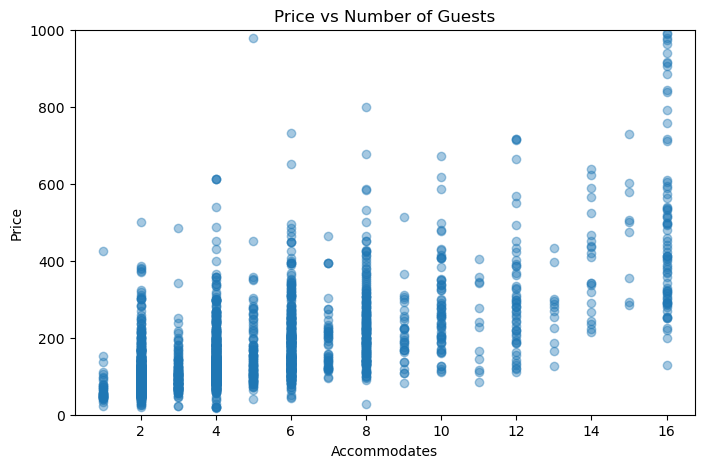

In [87]:
#price vs number of accommodates, just using up to $1000 to neglect outliers
plt.figure(figsize=(8,5))
plt.scatter(df["accommodates"], df["price"], alpha=0.4)
plt.ylim(0, 1000)
plt.xlabel("Accommodates")
plt.ylabel("Price")
plt.title("Price vs Number of Guests")
plt.show()

There is a general upward trend between the number of guests and the price of an airbnb.

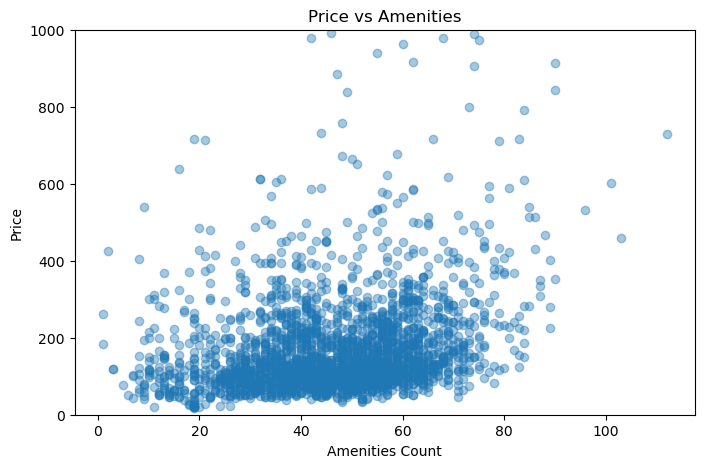

In [86]:
# price compared to amenities count, just using up to $1000 to neglect outliers
plt.figure(figsize=(8,5))
plt.scatter(df["amenities_count"], df["price"], alpha=0.4)
plt.ylim(0,  1000)
plt.xlabel("Amenities Count")
plt.ylabel("Price")
plt.title("Price vs Amenities")
plt.show()

While there still seems to be a positive correlation between the number of amenities and the price of the AirBnb, this seems to be quite a weak correlation in comparison to other elements, such as number of guests previously shown. 

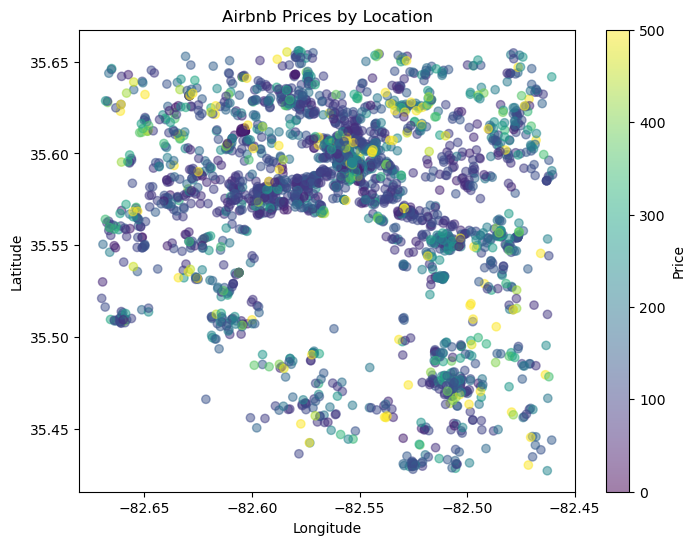

In [89]:
# looking at how location impacts prices, just using up to $1000 for clearer data
plt.figure(figsize=(8,6))
plt.scatter(
    df["longitude"],
    df["latitude"],
    c=df["price"],
    cmap="viridis",
    alpha=0.5,
    vmin = 0,
    vmax = 500
)
plt.colorbar(label="Price")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Airbnb Prices by Location")
plt.show()

Based on this visualization, it is clearly seen that there are higher concentrations of AirBnbs in certain areas, and that the higher concentration areas also contain more highly expensive AirBnbs. However, based on this, it is hard to determine whether there is actually a strong correlation between location and price, which will be easier to determine with a model. 